In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [5]:
df = pd.read_csv('amazon_clean_data.csv')

In [5]:
df.shape

(1465, 17)

In [6]:
df.drop('user_id', axis = 1, inplace = True)


In [7]:
df.drop('user_name', axis = 1, inplace = True)

In [8]:
df.drop('review_id', axis = 1, inplace = True)
df.drop('img_link', axis = 1, inplace = True)
df.drop('product_link', axis = 1, inplace = True)

In [9]:
df.drop('product_id', axis = 1, inplace = True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_name         1465 non-null   object 
 1   category             1465 non-null   object 
 2   discounted_price     1465 non-null   float64
 3   actual_price         1465 non-null   float64
 4   discount_percentage  1465 non-null   object 
 5   rating               1465 non-null   float64
 6   rating_count         1463 non-null   float64
 7   about_product        1465 non-null   object 
 8   review_title         1465 non-null   object 
 9   review_content       1465 non-null   object 
 10  discount             1465 non-null   float64
dtypes: float64(5), object(6)
memory usage: 126.0+ KB


In [10]:
df['discount_percentage'] = df['discount_percentage'].str.replace('%','').astype(float)


In [11]:
df['rating_count'].fillna(df['rating_count'].median(), inplace=True)

In [14]:
threshold = df['rating_count'].quantile(0.20)
df['low_selling'] = df['rating_count'] < threshold
df['low_selling'].unique()

array([ True, False])

In [12]:
df['low_selling'] = df['rating_count'] < df['rating_count'].median()

In [13]:
df['price_diff'] = df['actual_price'] - df['discounted_price']

In [14]:
df['desc_length'] = df['about_product'].apply(lambda x: len(x.split()))

In [18]:
df.groupby('low_selling')[['discounted_price','rating','rating_count','desc_length']].mean()

,discounted_price,rating,rating_count,desc_length
low_selling,,,,
False,3619.654292,4.145913,34879.043597,112.655313
True,2628.938687,4.041450,1608.094391,115.436389


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_name         1465 non-null   object 
 1   category             1465 non-null   object 
 2   discounted_price     1465 non-null   float64
 3   actual_price         1465 non-null   float64
 4   discount_percentage  1465 non-null   float64
 5   rating               1465 non-null   float64
 6   rating_count         1465 non-null   float64
 7   about_product        1465 non-null   object 
 8   review_title         1465 non-null   object 
 9   review_content       1465 non-null   object 
 10  discount             1465 non-null   float64
 11  low_selling          1465 non-null   bool   
 12  price_diff           1465 non-null   float64
 13  desc_length          1465 non-null   int64  
dtypes: bool(1), float64(7), int64(1), object(5)
memory usage: 150.3+ KB


<Axes: >

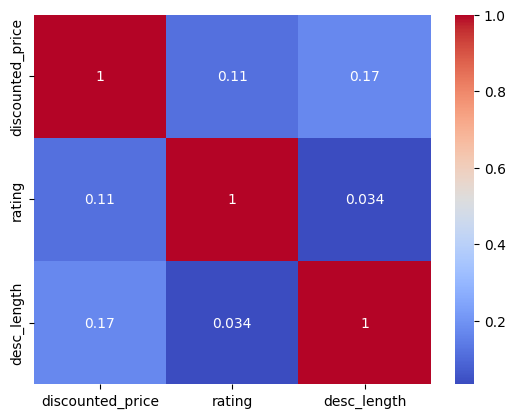

In [29]:
selected_features = ['discounted_price', 'rating', 'desc_length']
sns.heatmap(df[selected_features].corr(), annot=True, cmap='coolwarm')

In [15]:
df.drop('rating_count', axis = 1, inplace = True)

In [16]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove special chars
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

df['About_prod_clean'] = df['about_product'].apply(clean_text)

In [17]:
df = pd.get_dummies(df, columns=['category'], drop_first=True)

In [18]:
from textblob import TextBlob

df['review_sentiment'] = df['review_content'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [3]:
%pip install gensim

  Using cached gensim-4.4.0.tar.gz (23.3 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached smart_open-7.5.1-py3-none-any.whl.metadata (24 kB)
  Using cached wrapt-2.1.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (7.4 kB)
Using cached smart_open-7.5.1-py3-none-any.whl (64 kB)
Using cached wrapt-2.1.2-cp314-cp314-macosx_11_0_arm64.whl (61 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for gensim (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [596 lines of output]
      /private/var/folders/c3/1v5k993d3f147s1b3pwpmmxc0000gn/T/pip-build-env-5prkd2mk/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:287: UserWarning: Unknown distribution option: 'test_suite'
        warnings.warn(msg)
      /private/var/folders/c3/1v5k993d3f147s1b3pwpmmxc0000gn/T/pip-build-env-5prkd2mk/overlay/lib/python3.14/site-packages/setuptools/_distutils/dist.py:2

In [19]:
from gensim.models import Word2Vec

# Tokenize cleaned text
df['tokens'] = df['About_prod_clean'].apply(lambda x: x.split())

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=df['tokens'].tolist(),
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    epochs=10
)
print('Word2Vec model trained. Vocabulary size:', len(w2v_model.wv))

Word2Vec model trained. Vocabulary size: 13054


In [20]:
def get_avg_vector(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(vector_size)

w2v_vectors = np.array([get_avg_vector(tokens, w2v_model) for tokens in df['tokens']])
w2v_df = pd.DataFrame(w2v_vectors, columns=[f'w2v_{i}' for i in range(100)])
print('Word2Vec feature matrix shape:', w2v_df.shape)

Word2Vec feature matrix shape: (1465, 100)


In [21]:
df_final = pd.concat([df.reset_index(drop=True), w2v_df], axis=1)

In [22]:
df_final.drop(
    ['about_product', 'About_prod_clean', 'review_content', 'review_title', 'tokens'],
    axis=1,
    inplace=True
)

In [41]:
FEATURES = [
    'discounted_price',
    'actual_price',
    'discount_percentage',
    'rating',
    'discount',
    'price_diff',
    'desc_length',
    'review_sentiment',
]

X = df[FEATURES]
y = df['low_selling']
print('X shape:', X.shape, '| y shape:', y.shape)

In [42]:
X.drop('category_Computers&Accessories|Accessories&Peripherals|Adapters|USBtoUSBAdapters', axis=1, inplace=True, errors='ignore')

In [43]:
X.drop('category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCHeadsets', axis=1, inplace=True, errors='ignore')
X.drop('category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCMicrophones', axis=1, inplace=True, errors='ignore')
X.drop('category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|PCSpeakers', axis=1, inplace=True, errors='ignore')

In [44]:
X.drop('category_Computers&Accessories|Accessories&Peripherals|Audio&VideoAccessories|Webcams&VoIPEquipment|Webcams', axis=1, inplace=True, errors='ignore')
X.drop('category_Computers&Accessories|Accessories&Peripherals|Cables&Accessories|CableConnectionProtectors', axis=1, inplace=True, errors='ignore')
X.drop('category_Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|DVICables', axis=1, inplace=True, errors='ignore')

In [45]:
X.head()

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
])

pipeline.fit(X_train, y_train)
print('Pipeline trained successfully')

In [49]:
import joblib
import shap
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# ── Evaluate ──────────────────────────────────────────────────────
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Good Sales', 'Low Selling']))
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')

# ── SHAP: explain one sample ──────────────────────────────────────
scaler   = pipeline.named_steps['scaler']
rf_model = pipeline.named_steps['rf']

sample_raw    = X_test.iloc[[0]]
sample_scaled = scaler.transform(sample_raw)

explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(sample_scaled)

# Class-1 (Low Selling) SHAP values
sv = np.array(shap_values[1]).flatten() if isinstance(shap_values, list) \
     else np.array(shap_values).reshape(-1, len(FEATURES), 2)[0, :, 1]

# Top-3 contributors
top3 = sorted(zip(FEATURES, sv), key=lambda x: abs(x[1]), reverse=True)[:3]
print('\nTop-3 SHAP contributors (Low Selling):')
for feat, val in top3:
    print(f'  {feat:<25} SHAP = {val:+.4f}')

# ── Save pipeline ─────────────────────────────────────────────────
joblib.dump(pipeline, 'pipeline.pkl')
print('\nPipeline saved → pipeline.pkl')

In [58]:
import joblib
joblib.dump(rf, "model.pkl")

['model.pkl']